# 1. Entendimiento del problema
El gobierno Australiano quiere conocer cuanto puede ser el costo de el uso de corticoides y esteroides en el sistema de salud actual para preparar sus finanzas a futuro.

# 2. Enfoque analitico:
Vamos a construir un modelo de regresion basado en series de tiempo que permita estimar el costo de corticoides y esteroides con el menor MAE posible.  

# 3. Requerimiento de datos:
Se requiere los datos pasados del costo de los medicamentos.

# 4. Recolección de datos:

In [1]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [2]:
data = fetch_dataset(name='h2o_exog')
data.index.name = 'datetime'

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 3 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [3]:
data

,y,exog_1,exog_2
datetime,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199
...,...,...,...
2008-02-01,0.761822,1.515840,1.786373
2008-03-01,0.649435,1.506258,1.694264
2008-04-01,0.827887,1.505253,1.627135


# 5. Exploracion de datos
- Determinar la estacionaridad de la serie

In [4]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from skforecast.plot import set_dark_theme

set_dark_theme()

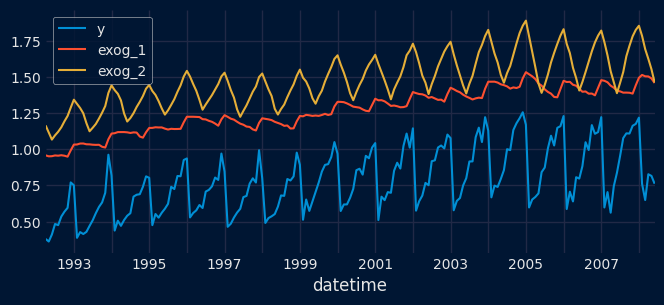

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
data.plot(ax=ax)
ax.legend()
plt.show()

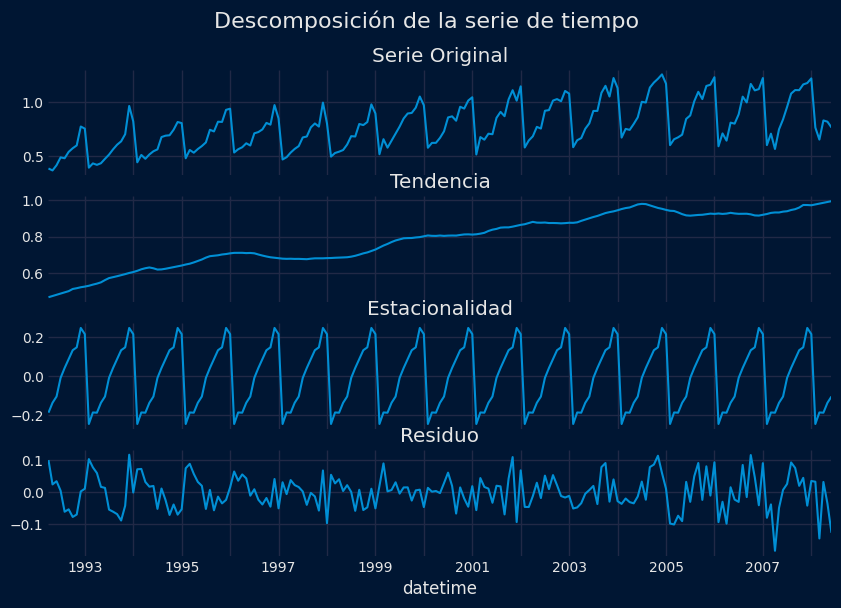

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

res_decompose = seasonal_decompose(data['y'], model='additive', extrapolate_trend='freq')
fig, ax = plt.subplots(4, 1, figsize=(9, 6), sharex=True)

res_decompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie Original')

res_decompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')

res_decompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Estacionalidad')

res_decompose.resid.plot(ax=ax[3])
ax[3].set_title('Residuo')

fig.suptitle('Descomposición de la serie de tiempo', fontsize=16)
plt.show()

In [7]:
def test_estacionaridad(series):
    adfuller_result = adfuller(series)
    print(f'ADF Estadistico: {adfuller_result[0]}')
    print(f'Valor p: {adfuller_result[1]}')

In [8]:
test_estacionaridad(data['y'])

ADF Estadistico: -1.5180458060933468
Valor p: 0.5245662008648657


# 6. Preparacion de datos

- Diferenciar la serie
- Identificar su comportamiento estacional

ADF Estadistico: -3.272501193023123
Valor p: 0.016153320135666022


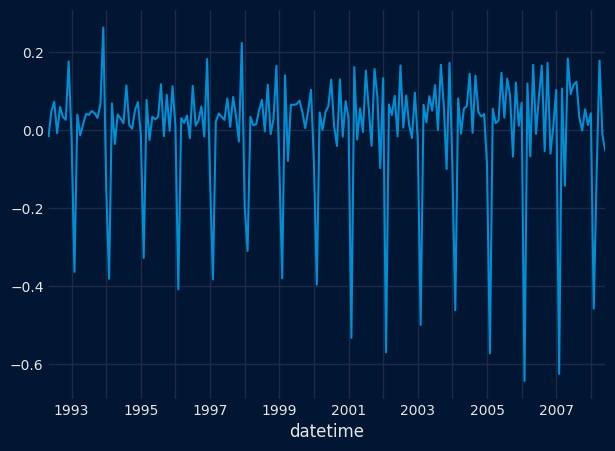

In [9]:
data_diff = data['y'].diff().dropna()
test_estacionaridad(data_diff)
data_diff.plot()
plt.show()

## Obtener valor q

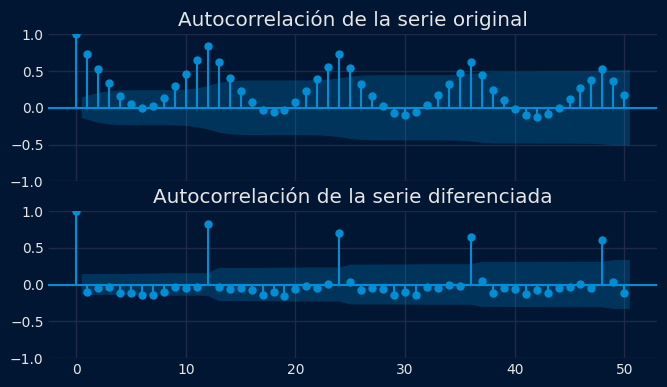

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

# Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

plot_acf(data['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación de la serie original')

plot_acf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación de la serie diferenciada')

plt.show()

## Obtener valor p

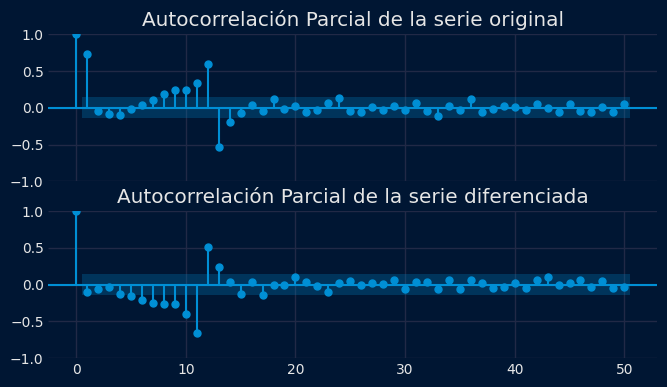

In [11]:
from statsmodels.graphics.tsaplots import plot_pacf

# Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

plot_pacf(data['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación Parcial de la serie original')

plot_pacf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación Parcial de la serie diferenciada')

plt.show()

## Diferenciacion de la serie estacionaria

In [12]:
data_diff_12 = data_diff.diff(12).dropna()
test_estacionaridad(data_diff_12)

ADF Estadistico: -5.177607779376001
Valor p: 9.766313840442693e-06


<Figure size 700x300 with 0 Axes>

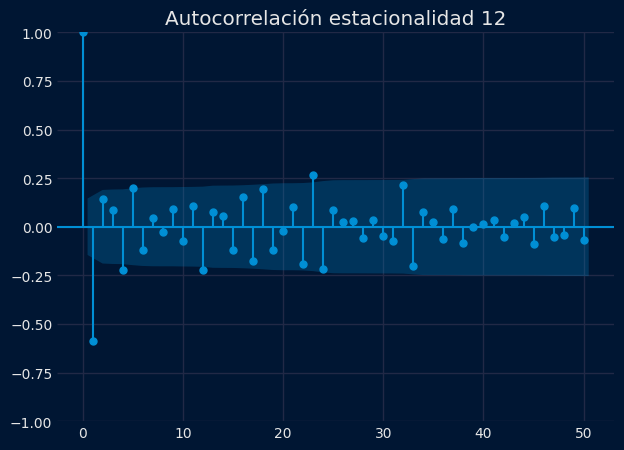

In [13]:
plt.figure(figsize=(7, 3))
plot_acf(data_diff_12, lags=50, alpha=0.05)
plt.title('Autocorrelación estacionalidad 12')
plt.show()

<Figure size 700x300 with 0 Axes>

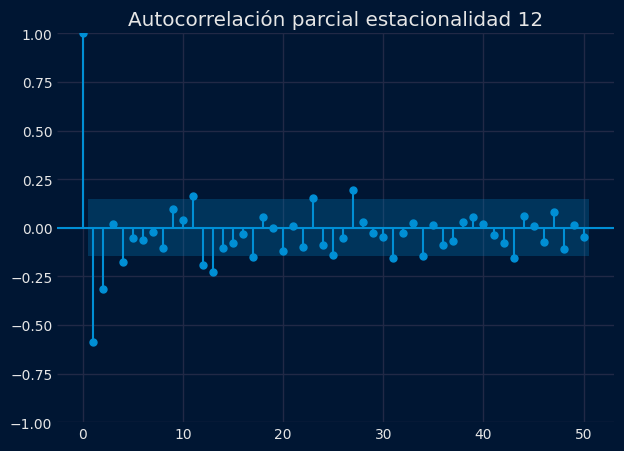

In [14]:
plt.figure(figsize=(7, 3))
plot_pacf(data_diff_12, lags=50, alpha=0.05)
plt.title('Autocorrelación parcial estacionalidad 12')
plt.show()

## Datos extraidos
![WhatsApp Image 2025-10-15 at 08.41.42_1276a518.jpg](<attachment:WhatsApp Image 2025-10-15 at 08.41.42_1276a518.jpg>)
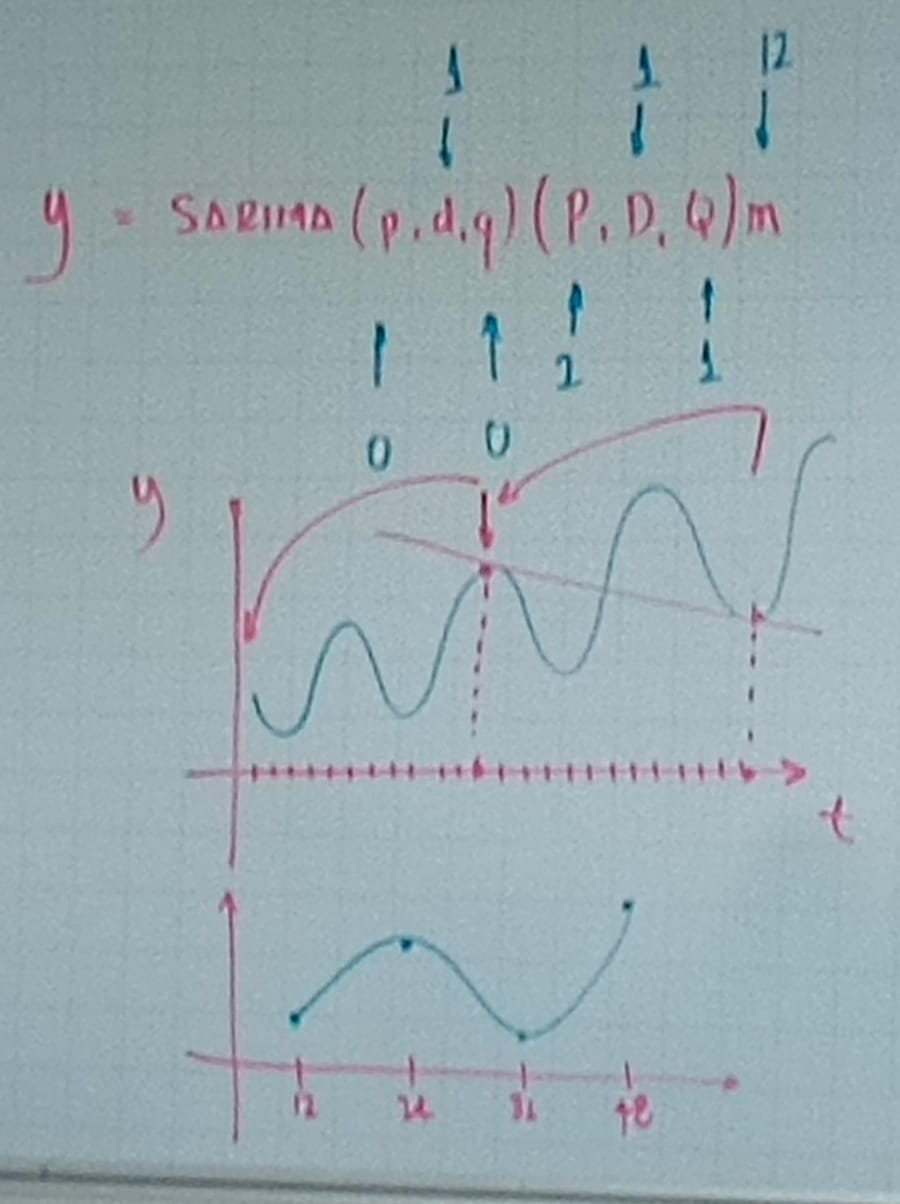

## Separacion datos entrenamiento y prueba

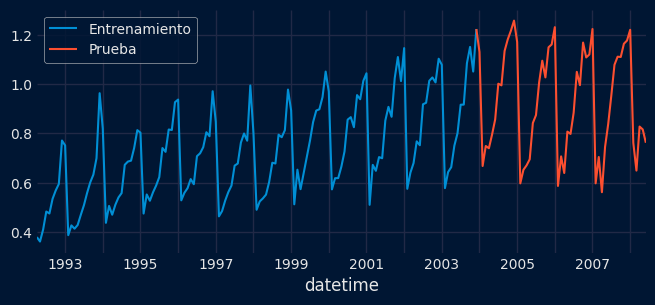

In [15]:
end_train = '2003-12-01'
data_train = data['y'].loc[:end_train]
data_test = data['y'].loc[end_train:]

plt.figure(figsize=(7, 3))
data_train.plot(label='Entrenamiento')
data_test.plot(label='Prueba')
plt.legend()
plt.show()

# 7. Modelado
- SARIMAX
- Forecaster
- RNA Secuencial

## SARIMAX

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarimax = SARIMAX(data_train, order=(0, 1, 0), seasonal_order=(2, 1, 1, 12))
modelo_sarimax_fit = modelo_sarimax.fit(disp = 0)
modelo_sarimax_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  141
Model:             SARIMAX(0, 1, 0)x(2, 1, [1], 12)   Log Likelihood                 178.682
Date:                              Mon, 20 Oct 2025   AIC                           -349.365
Time:                                      08:45:35   BIC                           -337.957
Sample:                                  04-01-1992   HQIC                          -344.729
                                       - 12-01-2003                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.4001      0.203      1.971      0.049       0.002       0.798
ar.S.L24      -0.2297      0.132     -1.739      0.082      -0.488       0.029
ma.S.L12      -0.8181      0.260     -3.148      0.002      -1.327      -0.309
sigma2         0.0033      0.000      7.708      0.000       0.002       0.004
===================================================================================
Ljung-Box (L1) (Q):                  35.77   Jarque-Bera (JB):                13.19
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.59   Skew:                            -0.46
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
pred_sarimax = modelo_sarimax_fit.get_forecast(steps=len(data_test)).predicted_mean
pred_sarimax.name = 'predicciones_sarimax'
display(pred_sarimax.head(4))

2004-01-01    1.153860
2004-02-01    0.719788
2004-03-01    0.792595
2004-04-01    0.791223
Freq: MS, Name: predicciones_sarimax, dtype: float64

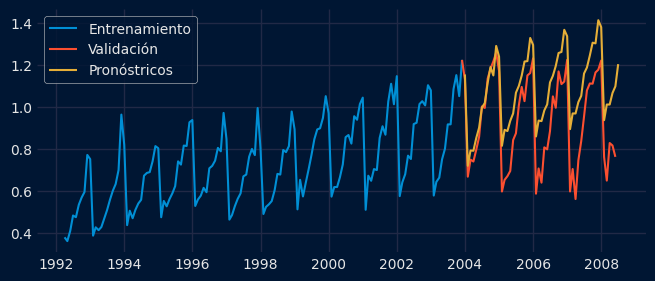

In [18]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(pred_sarimax, label='Pronóstricos')
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_percentage_error

mape_sarimax = mean_absolute_percentage_error(data_test, pred_sarimax)
print(f'MAPE: {mape_sarimax}')

MAPE: 0.2636046451459845


## Series de tiempo con ML

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import plot_prediction_intervals

### Forecaster 1 (RandomForestRegressor)

In [33]:
forecaster_1 = ForecasterRecursive(
  regressor=RandomForestRegressor(),
  lags=15,
  window_features=RollingFeatures(stats=['mean'], window_sizes=10)
)

forecaster_1.fit(y=data_train, store_in_sample_residuals=True)
forecaster_1

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-20 09:02:45 
Last fit date: 2025-10-20 09:02:45 
Skforecast version: 0.18.0 
Python version: 3.12.6 
Forecaster id: None

In [43]:
predictions_1 = forecaster_1.predict(steps=len(data_test))
predictions_1

2004-01-01    1.129040
2004-02-01    0.592217
2004-03-01    0.658608
2004-04-01    0.675519
2004-05-01    0.793151
2004-06-01    0.864258
2004-07-01    0.904293
2004-08-01    0.948114
2004-09-01    1.064226
2004-10-01    1.099358
2004-11-01    1.077068
2004-12-01    1.157363
2005-01-01    1.133236
2005-02-01    0.624447
2005-03-01    0.671788
2005-04-01    0.693907
2005-05-01    0.856192
2005-06-01    0.890057
2005-07-01    0.913438
2005-08-01    1.014212
2005-09-01    1.064905
2005-10-01    1.078699
2005-11-01    1.100686
2005-12-01    1.139984
2006-01-01    1.143886
2006-02-01    0.716171
2006-03-01    0.724605
2006-04-01    0.769349
2006-05-01    0.879611
2006-06-01    0.914379
2006-07-01    0.990707
2006-08-01    1.059388
2006-09-01    1.083680
2006-10-01    1.107229
2006-11-01    1.134905
2006-12-01    1.141092
2007-01-01    1.151783
2007-02-01    0.817019
2007-03-01    0.816654
2007-04-01    0.927076
2007-05-01    0.927461
2007-06-01    0.998717
2007-07-01    1.049872
2007-08-01 

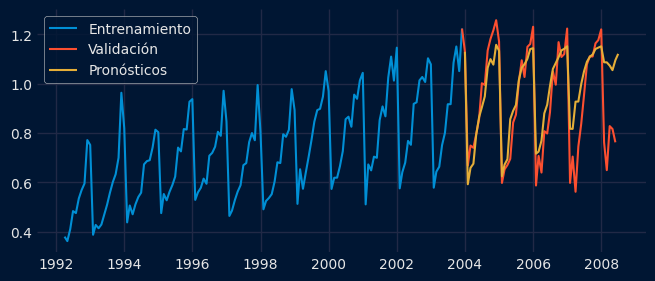

In [44]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_1, label='Pronósticos')
plt.legend()
plt.show()

In [36]:
mean_absolute_percentage_error(data_test, predictions_1)

0.17421444543034695

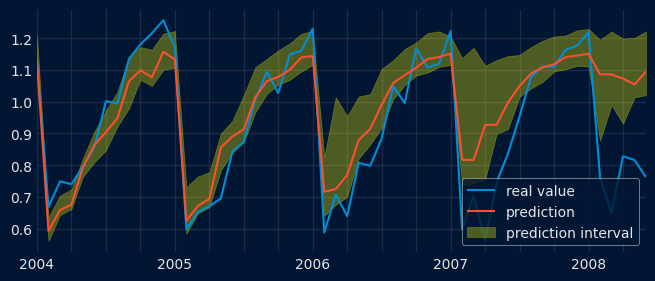

In [39]:
predictions_1_interval = forecaster_1.predict_interval(
    steps=len(data_test)-1,
    interval=[5, 95],
    method='bootstrapping',
    n_boot=100
)

plot_prediction_intervals(
  predictions=predictions_1_interval,
  y_true=data_test,
  target_variable='y',
  kwargs_fill_between={'color':'yellow', 'alpha':0.3},
)

plt.show()

### Forecaster 2 (DecisionTreeRegressor)

In [ ]:
forecaster_2 = ForecasterRecursive(
  regressor=DecisionTreeRegressor(random_state=42),
  lags=15,
  window_features=RollingFeatures(stats=['mean'], window_sizes=10)
)

forecaster_2.fit(y=data_train, store_in_sample_residuals=True)
forecaster_2

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-20 09:11:11 
Last fit date: 2025-10-20 09:11:11 
Skforecast version: 0.18.0 
Python version: 3.12.6 
Forecaster id: None

In [42]:
predictions_2 = forecaster_2.predict(steps=len(data_test))
predictions_2

2004-01-01    1.078145
2004-02-01    0.618996
2004-03-01    0.726520
2004-04-01    0.744324
2004-05-01    0.800746
2004-06-01    0.865984
2004-07-01    0.897900
2004-08-01    0.916887
2004-09-01    1.084659
2004-10-01    1.050838
2004-11-01    1.078145
2004-12-01    1.078145
2005-01-01    1.078145
2005-02-01    0.846186
2005-03-01    0.744324
2005-04-01    0.955421
2005-05-01    0.924368
2005-06-01    0.947281
2005-07-01    0.947281
2005-08-01    1.084659
2005-09-01    1.084659
2005-10-01    1.078145
2005-11-01    1.078145
2005-12-01    1.078145
2006-01-01    1.078145
2006-02-01    0.969656
2006-03-01    0.947281
2006-04-01    1.084659
2006-05-01    1.084659
2006-06-01    1.084659
2006-07-01    1.084659
2006-08-01    1.084659
2006-09-01    1.078145
2006-10-01    1.078145
2006-11-01    1.078145
2006-12-01    1.078145
2007-01-01    1.078145
2007-02-01    1.078145
2007-03-01    1.078145
2007-04-01    1.084659
2007-05-01    1.078145
2007-06-01    1.078145
2007-07-01    1.078145
2007-08-01 

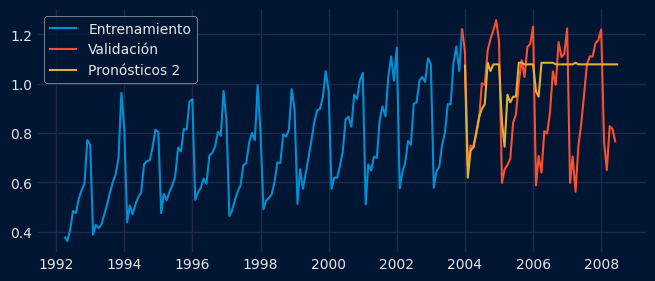

In [46]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_2, label='Pronósticos 2')
plt.legend()
plt.show()

In [48]:
mean_absolute_percentage_error(data_test, predictions_2)

0.2321745306768295

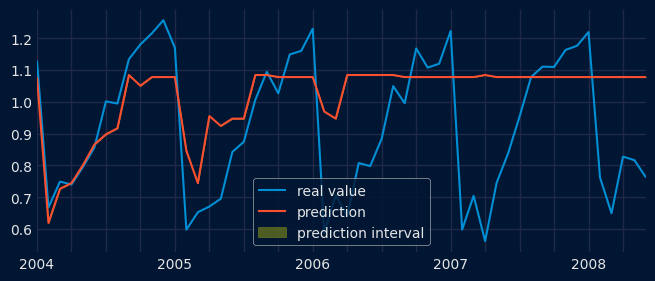

In [49]:
predictions_2_interval = forecaster_2.predict_interval(
    steps=len(data_test)-1,
    interval=[5, 95],
    method='bootstrapping',
    n_boot=100
)

plot_prediction_intervals(
  predictions=predictions_2_interval,
  y_true=data_test,
  target_variable='y',
  kwargs_fill_between={'color':'yellow', 'alpha':0.3},
)

plt.show()

### Forecaster 3 (DecisionTreeRegressor mejorado)

In [ ]:
from skforecast.model_selection import grid_search_forecaster, random_search_forecaster, TimeSeriesFold

In [61]:
forecaster_3 = ForecasterRecursive(
  regressor=DecisionTreeRegressor(random_state=42),
  lags=10,
)

# Busqueda de la ventana
lags_grid = {
  'lags_1': 3,
  'lags_2': 10,
  'lags_3': [1, 2, 3, 12],
}

# Busqueda de hiperparametros del regresor
param_grid = {
  'max_depth': [5, 10, 20],
  'criterion': ['squared_error', 'poisson', 'absolute_error', 'friedman_mse'],
}

# Folds
cv = TimeSeriesFold(
  steps=12,
  initial_train_size=len(data_test),
  refit=False
)

# Implementacion de la busqueda
results = grid_search_forecaster(
  forecaster=forecaster_3,
  y=data_train,
  param_grid=param_grid,
  lags_grid=lags_grid,
  cv=cv,
  metric='mean_squared_error',
  return_best=True,
  verbose=False,
  n_jobs=-1,
  show_progress=True
)
results

lags grid: 100%|██████████| 3/3 [00:10<00:00,  3.65s/it]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 12] 
  Parameters: {'criterion': 'absolute_error', 'max_depth': 5}
  Backtesting metric: 0.008137813902720652


,lags,lags_label,params,mean_squared_error,criterion,max_depth
0,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 5}",0.008138,absolute_error,5
1,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 10}",0.008439,absolute_error,10
2,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 20}",0.008439,absolute_error,20
3,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 10}",0.009701,friedman_mse,10
4,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 20}",0.009701,friedman_mse,20
5,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10}",0.009774,squared_error,10
6,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 20}",0.009774,squared_error,20
7,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5}",0.009899,squared_error,5
8,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5}",0.009899,friedman_mse,5
9,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 5}",0.021059,poisson,5


In [ ]:
forecaster_3

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3 12] 
Window features: None 
Window size: 12 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 5,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-20 09:29:31 
Last fit date: 2025-10-20 09:29:41 
Skforecast version: 0.18.0 
Python version: 3.12.6 
Forecaster id: None

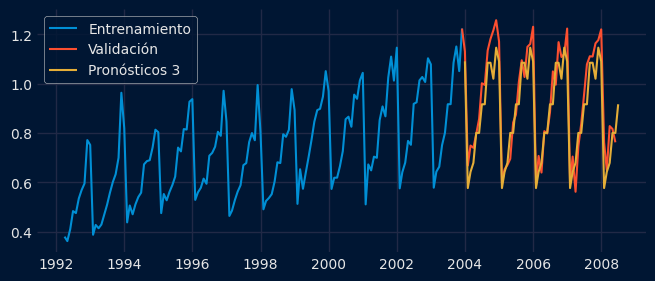

In [ ]:
predictions_3 = forecaster_3.predict(steps=len(data_test))

plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_3, label='Pronósticos 3')
plt.legend()
plt.show()

In [ ]:
mean_absolute_percentage_error(data_test, predictions_3)

0.11941843098736717

### Forecaster 4 (RandomForestRegressor mejorado)

In [63]:
forecaster_4 = ForecasterRecursive(
  regressor=RandomForestRegressor(random_state=42),
  lags=10,
)

# Busqueda de la ventana
lags_grid = {
  'lags_1': 3,
  'lags_2': 10,
  'lags_3': [1, 2, 3, 12],
}

# Busqueda de hiperparametros del regresor
param_grid = {
  'max_depth': [5, 10, 20],
  'criterion': ['squared_error', 'poisson', 'absolute_error', 'friedman_mse'],
  'n_estimators': [100, 200, 300]
}

# Folds
cv = TimeSeriesFold(
  steps=12,
  initial_train_size=len(data_test),
  refit=False
)

# Implementacion de la busqueda
results = grid_search_forecaster(
  forecaster=forecaster_4,
  y=data_train,
  param_grid=param_grid,
  lags_grid=lags_grid,
  cv=cv,
  metric='mean_squared_error',
  return_best=True,
  verbose=False,
  n_jobs=-1,
  show_progress=True
)
results

lags grid: 100%|██████████| 3/3 [01:23<00:00, 27.90s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 12] 
  Parameters: {'criterion': 'squared_error', 'max_depth': 5, 'n_estimators': 100}
  Backtesting metric: 0.011898283156282243


,lags,lags_label,params,mean_squared_error,criterion,max_depth,n_estimators
0,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5,...",0.011898,squared_error,5,100
1,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 5, 'n_es...",0.012169,poisson,5,100
2,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5, ...",0.012217,friedman_mse,5,100
3,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 20...",0.012255,squared_error,20,300
4,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10...",0.012255,squared_error,10,300
...,...,...,...,...,...,...,...
103,"[1, 2, 3]",lags_1,"{'criterion': 'friedman_mse', 'max_depth': 10,...",0.058632,friedman_mse,10,300
104,"[1, 2, 3]",lags_1,"{'criterion': 'poisson', 'max_depth': 5, 'n_es...",0.058792,poisson,5,300
105,"[1, 2, 3]",lags_1,"{'criterion': 'friedman_mse', 'max_depth': 5, ...",0.058869,friedman_mse,5,300
106,"[1, 2, 3]",lags_1,"{'criterion': 'poisson', 'max_depth': 10, 'n_e...",0.058931,poisson,10,300


In [64]:
forecaster_4

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3 12] 
Window features: None 
Window size: 12 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    5, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-20 09:42:51 
Last fit date: 2025-10-20 09:44:15 
Skforecast version: 0.18.0 
Python version: 3.12.6 
Forecaster id: None

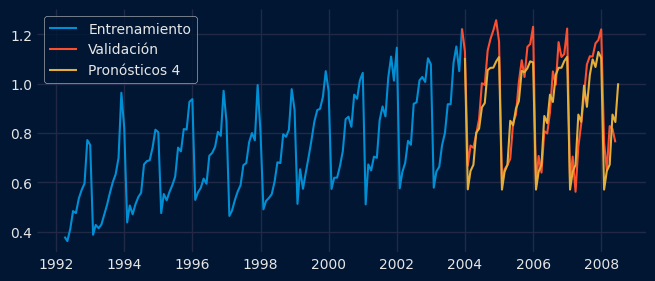

In [65]:
predictions_4 = forecaster_4.predict(steps=len(data_test))

plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(predictions_4, label='Pronósticos 4')
plt.legend()
plt.show()

In [66]:
mean_absolute_percentage_error(data_test, predictions_4)

0.13219829139884562